In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

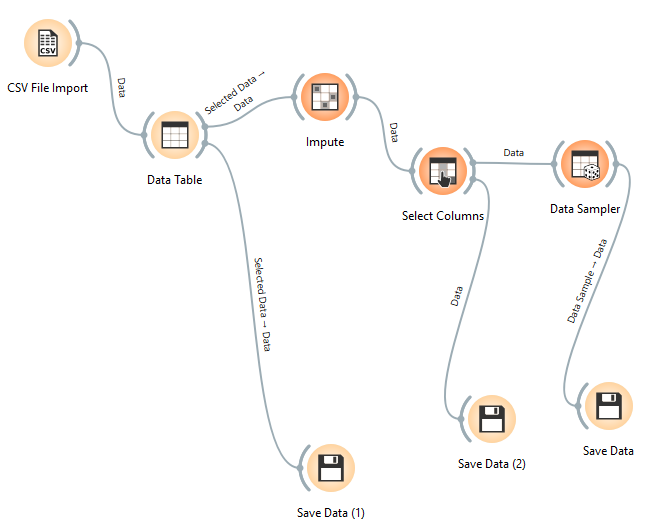


Esquema do Orange bem massa pra gente


## Dataset 1 — Appliances Energy Prediction (UCI) ##
https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction

Situação

Uma empresa de eficiência energética está analisando o comportamento de uma residência de baixo consumo. A equipe deseja identificar períodos de consumo elevado dos eletrodomésticos e observar quais condições de temperatura e umidade estavam presentes nesses momentos.
------------------------------------------------------------------------------

Etapa A — Orange Data Mining

Carregue o arquivo energydata_complete.csv no Orange Data Mining utilizando o widget File.

Inspecione os registros no Data Table e identifique os atributos de consumo, temperatura e umidade.

Utilize Select Columns para manter Appliances, lights, pelo menos três atributos de temperatura e três de umidade.

Verifique se existem valores ausentes. Este dataset é disponibilizado pelo UCI sem valores ausentes, mas a verificação deve fazer parte do procedimento.

Utilize Data Sampler para gerar uma amostra aleatória de 10% dos registros.

Exporte a amostra em CSV utilizando Save Data.
------------------------------------------------------------------------------

Etapa B — Python / Pandas

Carregue a amostra no Pandas e apresente head(), shape, info() e describe().

Renomeie Appliances para Consumo_Eletrodomesticos e simplifique o nome de pelo menos três atributos ambientais.

Determine o maior consumo de eletrodomésticos registrado na amostra.

Calcule um limiar correspondente a 70% do valor máximo e crie um DataFrame contendo somente os registros acima desse limite.

Conte os registros selecionados e calcule qual percentual da amostra eles representam.

Calcule a temperatura média de T1 e crie outro DataFrame contendo simultaneamente consumo acima de 70% do máximo e temperatura acima da média.

Compare os dois DataFrames e explique o efeito da inclusão da temperatura como segundo critério.

In [23]:
amostra1 = pd.read_csv('amostra10AEp.csv')

print("HEAD")
amostra1.head()

print("\nSHAPE")
amostra1.shape

print("\nINFO")
amostra1.info()

print("\nDESCRIBE")
amostra1.describe()

print("\nVALORES AUSENTES")
amostra1.isnull().sum().to_frame("Ausentes")

HEAD

SHAPE

INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1976 entries, 0 to 1975
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Appliances  1975 non-null   object
 1   lights      1975 non-null   object
 2   T1          1975 non-null   object
 3   RH_1        1975 non-null   object
 4   T2          1975 non-null   object
 5   RH_2        1975 non-null   object
 6   T3          1975 non-null   object
 7   RH_3        1975 non-null   object
dtypes: object(8)
memory usage: 123.6+ KB

DESCRIBE

VALORES AUSENTES


,Ausentes
Appliances,1
lights,1
T1,1
RH_1,1
T2,1
RH_2,1
T3,1
RH_3,1


In [31]:
# -------------- 1. Renomear as colunas para nomes mais fáceis
amostra1.rename(columns={
    "Appliances": "Consumo",
    "T1": "Temp_T1",
    "T2": "Temp_T2",
    "T3": "Temp_T3",
    "RH_1": "Umid_RH1",
    "RH_2": "Umid_RH2",
    "RH_3": "Umid_RH3"
}, inplace=True)

# -------------- 2. Converte para número na própria 'amostra1' -------------------- Deu erro dnv e usei a IA para corrigir
amostra1['Consumo'] = pd.to_numeric(amostra1['Consumo'], errors='coerce')

# -------------- 3. PMAX + P70 ---- Seguindo as instruções para fazer uma melhor análise do Data Frame
PMAX = amostra1['Consumo'].max()
P70 = 0.70 * PMAX

df1_alto = amostra1[amostra1["Consumo"] > P70]

print("Maior consumo:", PMAX)
print("Limite de 70%:", P70)
print("Registros acima do limite:", len(df1_alto))
print(f"Percentual: {len(df1_alto) / len(amostra1) * 100:.2f}%")

df1_alto.head()

Maior consumo: 770.0
Limite de 70%: 539.0
Registros acima do limite: 22
Percentual: 1.11%


,Consumo,lights,Temp_T1,Umid_RH1,Temp_T2,Umid_RH2,Temp_T3,Umid_RH3
354,620.0,0,24.39,44.3333,25.37,37.736,26.73,38.8633
429,650.0,0,20.89,36.7,18.29,39.6633,21.2,36
455,560.0,30,21.3567,36.09,19.5667,37.1633,21.6333,35.03
618,570.0,10,24.89,32.6667,23.56,31.14,23.6,30.8233
698,590.0,30,19.8567,47.6633,18.7,34.1,18.4267,37.8333


In [86]:
# ---------------- 4. Converte Temp_T1 para número (evita erro no cálculo da média) - Estava dando erros com mensagens estranhas, então usei a IA para me ajudar e resolver
amostra1["Temp_T1"] = pd.to_numeric(amostra1["Temp_T1"], errors='coerce')

# ---------------------------- 5. Calcular a temperatura média
media_temp1 = amostra1["Temp_T1"].mean()

# ------------------------------ 6. Data Frame Limiar P70 + Temperatura média
df1_alto_temp = amostra1[
    (amostra1["Consumo"] > P70) &
    (amostra1["Temp_T1"] > media_temp1)
]

# Mostrar resultados
print(f"Temperatura média de T1: {media_temp1:.2f}")
print(f"Somente consumo alto: {len(df1_alto)} registros")
print(f"Consumo alto + T1 acima da média: {len(df1_alto_temp)} registros")
print(f"Percentual: {len(df1_alto_temp) / len(amostra1) * 100:.2f}%")

Temperatura média de T1: 21.66
Somente consumo alto: 22 registros
Consumo alto + T1 acima da média: 8 registros
Percentual: 0.40%


In [87]:
df1_alto_temp.head()

,Consumo,lights,Temp_T1,Umid_RH1,Temp_T2,Umid_RH2,Temp_T3,Umid_RH3
354,620.0,0,24.3900,44.3333,25.37,37.736,26.73,38.8633
618,570.0,10,24.8900,32.6667,23.56,31.14,23.6,30.8233
918,750.0,30,22.4300,43,21.9267,40.1333,21.23,42.5967
995,690.0,10,22.5333,45.0267,22.0667,39.79,22.39,41.93
1184,600.0,20,24.8900,48.1333,28.9175,37.9475,27.1,42.44


Ao acrescentar a condição de temperatura acima da média, o filtro fica mais restritivo a valores mais altos, assim analisando uma parte específica do Data Frame que atende as condições de Temperatura e Consumo simultaneamente



## Dataset 2 — Steel Industry Energy Consumption (UCI) ##
https://archive.ics.uci.edu/dataset/851/steel+industry+energy+consumption

Situação

A equipe de gestão de energia de uma indústria siderúrgica deseja localizar situações de consumo elevado e verificar se esses períodos coincidem com condições de carga elevada ou valores menos favoráveis de fator de potência.

Etapa A — Orange Data Mining

Carregue o arquivo do dataset no File e visualize os registros no Data Table.

Utilize Select Columns para manter Usage_kWh, as variáveis de potência reativa, os fatores de potência, WeekStatus, Day_of_week e Load_Type.

Observe no Data Table quais valores aparecem em Load_Type e em WeekStatus.

Verifique a existência de valores ausentes.

Gere uma amostra aleatória de 20% utilizando Data Sampler.

Exporte a amostra em CSV.

Etapa B — Python / Pandas

Carregue a amostra e renomeie Usage_kWh para Consumo_kWh, simplificando também os nomes dos atributos de fator de potência.

Apresente uma inspeção inicial com head(), shape, info() e describe().

Determine o maior consumo registrado e calcule um limiar de 75% do consumo máximo.

Crie um DataFrame contendo os registros acima desse limiar e calcule a quantidade e o percentual de registros.

Verifique quantos registros desse DataFrame pertencem à categoria Maximum Load.

Escolha um dos atributos de fator de potência, observe seus valores e defina um limite coerente para representar valores mais baixos.

Crie um novo DataFrame contendo simultaneamente consumo elevado e fator de potência abaixo do limite escolhido.

Explique por que esse segundo conjunto de registros pode merecer maior atenção da equipe de energia.

In [39]:
amostra2 = pd.read_csv('amostra20SI.csv')

print("HEAD")
print(amostra2.head())

print("\nSHAPE")
print(amostra2.shape)

print("\nINFO")
amostra2.info()

print("\nDESCRIBE")
print(amostra2.describe())

print("\nVALORES AUSENTES")
amostra2.isnull().sum().to_frame("Ausentes")

HEAD
               date Lagging_Current_Reactive.Power_kVarh  \
0            string                           continuous   
1              meta                                  NaN   
2  29/04/2018 07:15                                 3.82   
3  04/10/2018 12:00                                48.02   
4  26/01/2018 11:30                                59.65   

  Leading_Current_Reactive_Power_kVarh Lagging_Current_Power_Factor  \
0                           continuous                   continuous   
1                                  NaN                          NaN   
2                                 0.00                        60.20   
3                                 0.00                        78.46   
4                                 0.00                        89.61   

  Leading_Current_Power_Factor         NSM  \
0                   continuous  continuous   
1                          NaN         NaN   
2                       100.00       26100   
3                      

,Ausentes
date,0
Lagging_Current_Reactive.Power_kVarh,1
Leading_Current_Reactive_Power_kVarh,1
Lagging_Current_Power_Factor,1
Leading_Current_Power_Factor,1
NSM,1
Load_Type,1
Usage_kWh,1
Day_of_week,1
WeekStatus,1


In [42]:
# -------------- 1. Renomear as colunas na própria tabela
amostra2.rename(columns={
    "Usage_kWh": "Consumo_kWh",
    "Lagging_Current_Power_Factor": "FP_Atrasado",
    "Leading_Current_Power_Factor": "FP_Adiantada"
}, inplace=True)

# -------------- 2. Converter para número ------- Estava dando erros com mensagens estranhas, então usei a IA para me ajudar e resolver
amostra2['Consumo_kWh'] = pd.to_numeric(amostra2['Consumo_kWh'], errors='coerce')
amostra2['FP_Adiantada'] = pd.to_numeric(amostra2['FP_Adiantada'], errors='coerce')

# -------------- 3. Calcular o consumo máximo e o limiar de 75%
max_consumo2 = amostra2['Consumo_kWh'].max()
limiar75_2 = 0.75 * max_consumo2

# -------------- 4. Filtrar consumos acima do limiar usando amostra2
df2_alto = amostra2[amostra2["Consumo_kWh"] > limiar75_2]

# -------------- 5. Contar registros e calcular percentual
qtd2 = len(df2_alto)
pct2 = (qtd2 / len(amostra2)) * 100

# -------------- 6. Contar registros de Maximum Load
qtd_maxload = (df2_alto["Load_Type"] == "Maximum Load").sum()

# Exibir resultados
print(f"Maior consumo: {max_consumo2:.2f} kWh")
print(f"Limiar de 75%: {limiar75_2:.2f} kWh")
print(f"Registros acima do limite: {qtd2}")
print(f"Percentual: {pct2:.2f}%")
print(f"Registros classificados como Maximum Load: {qtd_maxload}")

Maior consumo: 153.14 kWh
Limiar de 75%: 114.85 kWh
Registros acima do limite: 129
Percentual: 1.84%
Registros classificados como Maximum Load: 0


In [ ]:
# Definir limite do fator de potência
limite_fp = 90.0

# Filtrar consumo alto e fator de potência abaixo do limite
df2_alto_fp = df2_alto[
    df2_alto["FP_Atrasado"] < limite_fp
]

print(f"Limite do fator de potência: {limite_fp:.1f}%")
print(f"Consumo alto + fator de potência abaixo do limite: {len(df2_alto_fp)}")
print(f"Percentual da amostra: {len(df2_alto_fp) / len(dados2) * 100:.2f}%")

df2_alto_fp.head()

Limite do fator de potência: 90.0%
Consumo alto + fator de potência abaixo do limite: 156
Percentual da amostra: 0.45%


,date,Consumo_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),FP_Atrasado,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
140,02/01/2018 11:15,128.52,70.85,0.0,0.00,87.57,100.0,40500,Weekday,Tuesday,Maximum_Load
141,02/01/2018 11:30,144.47,78.48,0.0,0.00,87.87,100.0,41400,Weekday,Tuesday,Maximum_Load
143,02/01/2018 12:00,123.30,66.06,0.0,0.00,88.15,100.0,43200,Weekday,Tuesday,Maximum_Load
321,04/01/2018 08:30,136.19,74.88,0.0,0.06,87.63,100.0,30600,Weekday,Thursday,Light_Load
428,05/01/2018 11:15,129.85,63.86,0.0,0.06,89.74,100.0,40500,Weekday,Friday,Maximum_Load


O segundo conjunto combina consumo elevado com fator de potência abaixo do limite definido. Esse recorte merece maior atenção porque reúne alta demanda com uma condição menos favorável de fator de potência, embora não seja, sozinho, prova de falha.

## Dataset 3 — Power Consumption of Tetouan City (UCI) ##
https://archive.ics.uci.edu/dataset/849/power+consumption+of+tetouan+city

Situação

Uma equipe responsável pelo planejamento da distribuição de energia em Tétouan deseja identificar qual das três zonas apresenta o maior pico de consumo e observar as condições ambientais registradas nos momentos de maior demanda.

Etapa A — Orange Data Mining

Carregue o dataset e visualize os registros.

Utilize Select Columns para manter as três variáveis de consumo, Temperature, Humidity e Wind Speed.

Observe no Data Table a escala de valores das três zonas de consumo.

Verifique se existem valores ausentes.

Gere uma amostra aleatória de 15% dos registros.

Exporte a amostra em CSV.

Etapa B — Python / Pandas

Renomeie as três variáveis de consumo para Consumo_Zona_1, Consumo_Zona_2 e Consumo_Zona_3.

Determine o consumo máximo registrado em cada uma das três zonas.

Identifique qual zona apresenta o maior pico de consumo na amostra.

Para a zona identificada, calcule 70% do valor máximo e crie um DataFrame com os registros acima desse limiar.

Conte os registros e calcule o percentual que eles representam.

Calcule a temperatura média e crie um segundo DataFrame contendo consumo acima do limiar e temperatura acima da média.

Compare os dois conjuntos e explique o que ocorreu com a quantidade de registros após a inclusão da condição ambiental.

In [43]:
amostra3 = pd.read_csv('amostra15PCTC.csv')

print("HEAD")
amostra3.head()

print("\nSHAPE")
amostra3.shape

print("\nINFO")
amostra3.info()

print("\nDESCRIBE")
amostra3.describe()

print("\nVALORES AUSENTES")
amostra3.isnull().sum().to_frame("Ausentes")

HEAD

SHAPE

INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7865 entries, 0 to 7864
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   DateTime                   7865 non-null   object
 1   Temperature                7864 non-null   object
 2   Humidity                   7864 non-null   object
 3   Wind Speed                 7864 non-null   object
 4   Zone 1 Power Consumption   7864 non-null   object
 5   Zone 2  Power Consumption  7864 non-null   object
 6   Zone 3  Power Consumption  7864 non-null   object
dtypes: object(7)
memory usage: 430.2+ KB

DESCRIBE

VALORES AUSENTES


,Ausentes
DateTime,0
Temperature,1
Humidity,1
Wind Speed,1
Zone 1 Power Consumption,1
Zone 2 Power Consumption,1
Zone 3 Power Consumption,1


In [53]:
# -------------- 1. Renomear as colunas
dados3 = amostra3.rename(columns={
    "Zone 1 Power Consumption": "Consumo_Zona_1",
    "Zone 2  Power Consumption": "Consumo_Zona_2",
    "Zone 3  Power Consumption": "Consumo_Zona_3"
})

# -------------- 2. Garantir que as colunas sejam numéricas -- Estava dando erros com mensagens estranhas, então usei a IA para me ajudar e resolver
colunas_zonas = ["Consumo_Zona_1", "Consumo_Zona_2", "Consumo_Zona_3"]
for col in colunas_zonas:
    dados3[col] = pd.to_numeric(dados3[col], errors='coerce')

# -------------- 3. Encontrar o maior consumo de cada zona
maximos3 = dados3[colunas_zonas].max()

print("------- Picos por Zona -------")
print(maximos3)
print("-" * 30)

# -------------- 4. Encontrar a zona com maior pico geral
zona_maior3 = maximos3.idxmax()
maior3 = maximos3.max()

print(f"Zona com maior pico: {zona_maior3}")
print(f"Maior valor observado: {maior3:.2f}")

------- Picos por Zona -------
Consumo_Zona_1    51571.49834
Consumo_Zona_2    36437.20000
Consumo_Zona_3    47441.70000
dtype: float64
------------------------------
Zona com maior pico: Consumo_Zona_1
Maior valor observado: 51571.50


In [54]:
# 1. Garantir que a coluna 'Temperature' seja numérica --------- Mesma coisa, dando erros que não faziam sentido
dados3["Temperature"] = pd.to_numeric(dados3["Temperature"], errors='coerce')

#  -------------- 2. Calcular o limite de 70% do maior pico
limiar70_3 = 0.70 * maior3

# -------------- 3. Filtrar registros acima do limite
df3_alto = dados3[
    dados3[zona_maior3] > limiar70_3
]

# Quantidade e percentual
qtd3 = len(df3_alto)
pct3 = (qtd3 / len(dados3)) * 100

# -------------- 4. Calcular temperatura média
media_temp3 = dados3["Temperature"].mean()

# -------------- 5. Filtrar consumo alto e temperatura acima da média
df3_alto_temp = dados3[
    (dados3[zona_maior3] > limiar70_3) &
    (dados3["Temperature"] > media_temp3)
]

# Imprimir resultados
print(f"Limiar de 70%: {limiar70_3:.2f}")
print(f"Registros acima do limiar: {qtd3}")
print(f"Percentual: {pct3:.2f}%")
print(f"Temperatura média: {media_temp3:.2f}")
print(f"Com temperatura acima da média: {len(df3_alto_temp)}")
print(f"Percentual do segundo conjunto: {len(df3_alto_temp) / len(dados3) * 100:.2f}%")

Limiar de 70%: 36100.05
Registros acima do limiar: 2388
Percentual: 30.36%
Temperatura média: 18.79
Com temperatura acima da média: 1597
Percentual do segundo conjunto: 20.31%


In [85]:
df3_alto_temp.head()

,DateTime,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
14,6/5/2017 23:30,21.03,86.50,0.068,40993.90728,25383.4,24960.0
16,8/23/2017 17:50,27.06,47.58,4.905,37475.16093,24276.2,25140.6
21,6/22/2017 2:40,19.20,65.81,4.924,40676.02649,24754.7,25095.9
23,8/23/2017 13:50,27.11,43.35,4.906,40256.07103,27416.3,25453.5
27,7/12/2017 9:50,26.92,70.20,4.909,36511.89369,25906.3,25654.9


Incluir a temperatura acima da média cria uma segunda condição. O conjunto resultante é mais específico e, normalmente, menor que o conjunto formado apenas pelo critério de consumo.

## Dataset 4 — Solar Power Generation Data (Kaggle) ##
https://www.kaggle.com/datasets/anikannal/solar-power-generation-data

Situação

Uma equipe de operação de uma usina fotovoltaica deseja localizar períodos de alta geração e identificar quais inversores aparecem com maior frequência nesses momentos. Nesta atividade, o foco inicial será o arquivo de geração da planta, sem realizar junção com o arquivo de sensores.

Etapa A — Orange Data Mining

Abra um dos arquivos de geração da planta no File.

Inspecione os atributos no Data Table.

Utilize Select Columns para manter DATE_TIME, SOURCE_KEY, DC_POWER, AC_POWER, DAILY_YIELD e TOTAL_YIELD.

Observe a presença de registros com potência igual a zero e a faixa de valores de AC_POWER.

Gere uma amostra aleatória de 20% dos registros.

Exporte a amostra em CSV.

Etapa B — Python / Pandas

Carregue a amostra e renomeie as principais variáveis para nomes mais claros, como Potencia_CC, Potencia_CA e Geracao_Diaria.

Apresente head(), shape, info() e describe().

Determine a maior potência CA registrada.

Calcule um limiar correspondente a 70% da potência CA máxima.

Crie um DataFrame contendo somente registros acima desse limite e calcule sua quantidade e percentual.

Utilize value_counts() em SOURCE_KEY dentro do DataFrame de alta geração.

Identifique qual inversor aparece com maior frequência nos registros de alta geração e descreva o que esse resultado permite observar, sem concluir desempenho ou falha apenas com esse recorte.

In [26]:
amostra4 = pd.read_csv('amostra20PG.csv')
print("HEAD")
amostra4.head()

print("\nSHAPE")
amostra4.shape

print("\nINFO")
amostra4.info()

print("\nDESCRIBE")
amostra4.describe()

print("\nRegistros com AC_POWER igual a zero:",
      (amostra4["AC_POWER"] == 0).sum())

HEAD

SHAPE

INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13758 entries, 0 to 13757
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   DATE_TIME    13758 non-null  object
 1   SOURCE_KEY   13757 non-null  object
 2   DC_POWER     13757 non-null  object
 3   AC_POWER     13757 non-null  object
 4   DAILY_YIELD  13757 non-null  object
 5   TOTAL_YIELD  13757 non-null  object
dtypes: object(6)
memory usage: 645.0+ KB

DESCRIBE

Registros com AC_POWER igual a zero: 0


In [66]:
# -------------- 1. Renomear as colunas
dados4 = amostra4.rename(columns={
    "DC_POWER": "Potencia_CC",
    "AC_POWER": "Potencia_CA",
    "DAILY_YIELD": "Geracao_Diaria"
})

# -------------- 2. Converter a coluna para número (evita o erro TypeError) ---------- dando erro dnv, que estranho
dados4["Potencia_CA"] = pd.to_numeric(dados4["Potencia_CA"], errors='coerce')

# -------------- 3. Encontrar a maior potência CA
max_ca4 = dados4["Potencia_CA"].max()

# -------------- 4. Calcular o limite de 70%
limiar70_4 = 0.70 * max_ca4

# -------------- 5. Filtrar registros acima do limite
df4_alto = dados4[dados4["Potencia_CA"] > limiar70_4]

# -------------- 6. Calcular quantidade e percentual
qtd4 = len(df4_alto)
pct4 = (qtd4 / len(dados4)) * 100

print(f"Maior potência CA: {max_ca4:.2f}")
print(f"Limiar de 70%: {limiar70_4:.2f}")
print(f"Registros de alta geração: {qtd4}")
print(f"Percentual: {pct4:.2f}%")

# Contagem de ocorrências de cada inversor no grupo de alta geração
contagem_inversores = df4_alto["SOURCE_KEY"].value_counts()

print("Frequência dos inversores em alta geração:")
print(contagem_inversores)



Maior potência CA: 1405.59
Limiar de 70%: 983.91
Registros de alta geração: 1185
Percentual: 8.61%
Frequência dos inversores em alta geração:
SOURCE_KEY
adLQvlD726eNBSB    68
McdE0feGgRqW7Ca    65
ZnxXDlPa8U1GXgE    63
pkci93gMrogZuBj    62
ZoEaEvLYb1n2sOq    61
1IF53ai7Xc0U56Y    59
YxYtjZvoooNbGkE    58
sjndEbLyjtCKgGv    57
z9Y9gH1T5YWrNuG    56
uHbuxQJl8lW7ozc    55
zVJPv84UY57bAof    54
zBIq5rxdHJRwDNY    53
ih0vzX44oOqAx2f    53
WRmjgnKYAwPKWDb    52
3PZuoBAID5Wc2HD    51
iCRJl6heRkivqQ3    51
VHMLBKoKgIrUVDU    51
wCURE6d3bPkepu2    49
rGa61gmuvPhdLxV    43
7JYdWkrLSPkdwr4    43
1BY6WEcLGh8j5v7    42
bvBOhCH3iADSZry    39
Name: count, dtype: int64


In [84]:
df4_alto.head()

,DATE_TIME,SOURCE_KEY,Potencia_CC,Potencia_CA,Geracao_Diaria,TOTAL_YIELD
13,26-05-2020 12:15,bvBOhCH3iADSZry,11830.1,1153.83,4028.14,6396364.143
48,15-06-2020 14:30,wCURE6d3bPkepu2,10571.3,1032.07,5366.57,7015064.571
50,25-05-2020 10:15,z9Y9gH1T5YWrNuG,11050.1,1079.86,2174.29,7082812.286
74,13-06-2020 11:30,7JYdWkrLSPkdwr4,11094.5,1082.44,3570.25,7815987.250
78,07-06-2020 13:00,VHMLBKoKgIrUVDU,12663.4,1234.69,4976.71,7382965.714


`value_counts()` mostra quantas vezes os inversores aparecem. E quem aparece com mais frequência é o inversor adLQvlD726eNBSB.
Esse resultado permite observar a frequência de participação no recorte, mas não permite concluir sozinho que o inversor é melhor, pior ou apresenta defeito.

## Dataset 5 — Wind & Solar Energy Production (Kaggle) ##
https://www.kaggle.com/datasets/ahmeduzaki/wind-and-solar-energy-production-dataset

Situação

Um operador de um portfólio de fontes renováveis deseja comparar a ocorrência de períodos de alta produção solar e alta produção eólica. Como as duas fontes possuem escalas próprias, cada uma deverá ser comparada com o seu próprio valor máximo.

Etapa A — Orange Data Mining

Carregue o dataset e visualize os atributos disponíveis.

Utilize Select Columns para manter os atributos temporais e as variáveis de produção solar e eólica.

Observe os valores mínimos e máximos das duas variáveis de geração.

Verifique a existência de valores ausentes.

Gere uma amostra aleatória de 20% dos registros.

Exporte a amostra em CSV.

Etapa B — Python / Pandas

Renomeie as variáveis principais para Geracao_Solar e Geracao_Eolica.

Determine o valor máximo registrado para cada fonte.

Calcule separadamente 70% do máximo solar e 70% do máximo eólico.

Crie um DataFrame para registros de alta geração solar e outro para registros de alta geração eólica.

Conte os registros de cada DataFrame e calcule seus respectivos percentuais.

Compare qual fonte aparece com maior frequência acima de 70% do seu próprio máximo.

Explique por que não seria adequado utilizar diretamente o mesmo valor numérico de potência como limite para as duas fontes sem antes observar a escala de cada variável.

In [61]:
amostra5 = pd.read_csv('amostra20WSEP.csv')

print("HEAD")
amostra5.head()

print("\nSHAPE")
amostra5.shape

print("\nINFO")
amostra5.info()

print("\nDESCRIBE")
amostra5.describe()

print("\nVALORES AUSENTES")
amostra5.isnull().sum().to_frame("Ausentes")

HEAD

SHAPE

INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10375 entries, 0 to 10374
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        10375 non-null  object
 1   Start_Hour  10374 non-null  object
 2   End_Hour    10374 non-null  object
 3   Source      10374 non-null  object
 4   Production  10374 non-null  object
 5   Month_Name  10374 non-null  object
 6   Day_Name    10374 non-null  object
 7   Season      10374 non-null  object
dtypes: object(8)
memory usage: 648.6+ KB

DESCRIBE

VALORES AUSENTES


,Ausentes
Date,0
Start_Hour,1
End_Hour,1
Source,1
Production,1
Month_Name,1
Day_Name,1
Season,1


In [81]:
# -------------- 1. Converter a coluna 'Production' para número PRIMEIRO --------- Deu erro dnv ;-;
amostra5["Production"] = pd.to_numeric(amostra5["Production"], errors='coerce')

# -------------- 2. Agora sim, separar Solar e Eólica
solar = amostra5[amostra5["Source"] == "Solar"]
eolica = amostra5[amostra5["Source"] == "Wind"]

# -------------- 3. Obter os valores máximos
max_solar6 = solar["Production"].max()
max_eolica6 = eolica["Production"].max()

# -------------- 4. Calcular 70% dos máximos
limiar_solar6 = max_solar6 * 0.70
limiar_eolica6 = max_eolica6 * 0.70

# -------------- 5. Data Frames
df6_solar = solar[solar["Production"] > limiar_solar6]
df6_eolica = eolica[eolica["Production"] > limiar_eolica6]

# -------------- 6. Quantidade e percentuais
qtd_solar6 = len(df6_solar)
qtd_eolica6 = len(df6_eolica)



pct_solar6 = (qtd_solar6 / len(solar) * 100) if len(solar) > 0 else 0
pct_eolica6 = (qtd_eolica6 / len(eolica) * 100) if len(eolica) > 0 else 0

# Exibir resultados
print(f"Máximo solar: {max_solar6:.2f}")
print(f"Máximo eólico: {max_eolica6:.2f}")

print(f"70% do máximo solar: {limiar_solar6:.2f}")
print(f"70% do máximo eólico: {limiar_eolica6:.2f}")

print(f"\nAlta geração solar: {qtd_solar6} ({pct_solar6:.2f}%)")
print(f"Alta geração eólica: {qtd_eolica6} ({pct_eolica6:.2f}%)")
df6_eolica.head()
df6_solar.head()

if pct_solar6 > pct_eolica6:
    print("Maior frequência: SOLAR")
elif pct_eolica6 > pct_solar6:
    print("Maior frequência: EÓLICA")
else:
    print("Frequências iguais")



Máximo solar: 16316.00
Máximo eólico: 22929.00
70% do máximo solar: 11421.20
70% do máximo eólico: 16050.30

Alta geração solar: 45 (2.44%)
Alta geração eólica: 245 (2.87%)
Maior frequência: EÓLICA


In [82]:
df6_solar.head()


,Date,Start_Hour,End_Hour,Source,Production,Month_Name,Day_Name,Season
79,7/8/2025,13,14,Solar,13125.0,July,Tuesday,Summer
180,3/19/2025,13,14,Solar,13786.0,March,Wednesday,Spring
185,8/17/2025,12,13,Solar,11455.0,August,Sunday,Summer
189,7/16/2025,12,13,Solar,16160.0,July,Wednesday,Summer
209,3/31/2025,12,13,Solar,12441.0,March,Monday,Spring


In [83]:
df6_eolica.head()

,Date,Start_Hour,End_Hour,Source,Production,Month_Name,Day_Name,Season
22,1/3/2024,0,1,Wind,17272.0,January,Wednesday,Winter
34,3/11/2021,13,14,Wind,16144.0,March,Thursday,Spring
105,1/29/2025,0,1,Wind,18199.0,January,Wednesday,Winter
153,12/8/2024,6,7,Wind,16946.0,December,Sunday,Winter
194,11/19/2024,2,3,Wind,16568.0,November,Tuesday,Fall


Cada fonte é comparada com o seu próprio máximo. Isso evita comparar diretamente números de escalas diferentes. A fonte com maior percentual de registros acima de 70% do próprio máximo é a que aparece com maior frequência relativa de alta produção.

## Dataset 6 — Individual Household Electric Power Consumption (UCI)  ##

Situação

Uma residência possui monitoramento elétrico detalhado e deseja identificar episódios de demanda elevada que também apresentem corrente acima do comportamento médio. O dataset é o mesmo utilizado como referência em aula, mas o critério de análise será diferente.

Etapa A — Orange Data Mining

Carregue novamente o dataset original no File, e não a amostra utilizada anteriormente.

Inspecione os dados no Data Table e verifique os registros com valores ausentes.

Realize o tratamento dos dados ausentes conforme o procedimento trabalhado em aula.

Utilize Select Columns para manter Global_active_power, Global_reactive_power, Voltage, Global_intensity e os três atributos Sub_metering.

Gere uma nova amostra aleatória de 10% dos dados tratados.

Exporte a amostra em CSV.

Etapa B — Python / Pandas

Carregue a nova amostra e organize os atributos utilizando nomes mais simples.

Determine o valor máximo de potência ativa.

Calcule 75% do valor máximo e crie um DataFrame contendo registros acima desse limite.

Calcule a quantidade e o percentual de registros selecionados.

Calcule a corrente média da amostra.

Crie um segundo DataFrame contendo simultaneamente potência ativa acima de 75% do máximo e corrente acima da média.

Compare os dois conjuntos e explique o efeito da inclusão da corrente como segunda condição.

In [28]:
amostra7 = pd.read_csv('amostra10IHEPC.csv')

print("HEAD")
amostra7.head()

print("\nSHAPE")
amostra7.shape

print("\nINFO")
amostra7.info()

print("\nDESCRIBE")
amostra7.describe()

print("\nVALORES AUSENTES")
amostra7.isnull().sum().to_frame("Ausentes")

/tmp/ipykernel_960/448930757.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  amostra7 = pd.read_csv('amostra10IHEPC.csv')


HEAD

SHAPE

INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204930 entries, 0 to 204929
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Global_active_power    204929 non-null  object
 1   Global_reactive_power  204929 non-null  object
 2   Voltage                204929 non-null  object
 3   Global_intensity       204929 non-null  object
 4   Sub_metering_1         204929 non-null  object
 5   Sub_metering_2         204929 non-null  object
 6   Sub_metering_3         204929 non-null  object
dtypes: object(7)
memory usage: 10.9+ MB

DESCRIBE

VALORES AUSENTES


,Ausentes
Global_active_power,1
Global_reactive_power,1
Voltage,1
Global_intensity,1
Sub_metering_1,1
Sub_metering_2,1
Sub_metering_3,1


In [73]:
# -------------- 1. Renomear as colunas
dados7 = amostra7.rename(columns={
    "Global_active_power": "Potencia_Ativa",
    "Global_reactive_power": "Potencia_Reativa",
    "Voltage": "Tensao",
    "Global_intensity": "Corrente",
    "Sub_metering_1": "Sub_Medicao_1",
    "Sub_metering_2": "Sub_Medicao_2",
    "Sub_metering_3": "Sub_Medicao_3"
})

# -------------- 2. Converter para número (evita erro no .max() e na comparação) ---------- Tava dando erro dnv, sem eu ter o conhecimento disso :C
dados7["Potencia_Ativa"] = pd.to_numeric(dados7["Potencia_Ativa"], errors='coerce')
dados7["Corrente"] = pd.to_numeric(dados7["Corrente"], errors='coerce')

# -------------- 3. Calcular o valor máximo e o limiar de 75%
max_pot7 = dados7["Potencia_Ativa"].max()
limiar75_7 = max_pot7 * 0.75

# -------------- 4. Filtrar registros acima do limite
df7_alto = dados7[dados7["Potencia_Ativa"] > limiar75_7]

# -------------- 5. Calcular quantidade e percentual
qtd7 = len(df7_alto)
pct7 = (qtd7 / len(dados7)) * 100

print(f"Potência ativa máxima: {max_pot7:.3f}")
print(f"Limiar de 75%: {limiar75_7:.3f}")
print(f"Registros acima do limite: {qtd7}")
print(f"Percentual: {pct7:.2f}%")
df7_alto.head()

Potência ativa máxima: 10.536
Limiar de 75%: 7.902
Registros acima do limite: 58
Percentual: 0.03%


,Potencia_Ativa,Potencia_Reativa,Tensao,Corrente,Sub_Medicao_1,Sub_Medicao_2,Sub_Medicao_3
3134,8.540,0.238,236.23,36.0,80,35,17
3632,8.278,0.088,231.5,35.6,0,71,17
10341,8.026,0.066,236.45,33.8,37,73,18
11697,8.102,0.19,229.31,35.4,35,35,17
27985,10.290,0.302,230.9,44.6,35,66,17


In [88]:
# -------------- 6. Calcular a corrente média
media_corrente7 = dados7["Corrente"].mean()

# -------------- 7. Filtrar potência elevada e corrente acima da média
df8_altoMePA = dados7[
    (dados7["Potencia_Ativa"] > limiar75_7) & (dados7["Corrente"] > media_corrente7)
]

# Exibir resultados
print(f"Corrente média: {media_corrente7:.3f}")
print(f"Somente potência elevada: {len(df7_alto)} registros")
print(f"Potência elevada + corrente acima da média: {len(alto_corrente7)} registros")
print(f"Percentual: {len(alto_corrente7) / len(dados7) * 100:.2f}%")
df8_altoMePA.head()

Corrente média: 4.634
Somente potência elevada: 58 registros
Potência elevada + corrente acima da média: 58 registros
Percentual: 0.03%


,Potencia_Ativa,Potencia_Reativa,Tensao,Corrente,Sub_Medicao_1,Sub_Medicao_2,Sub_Medicao_3
3134,8.540,0.238,236.23,36.0,80,35,17
3632,8.278,0.088,231.5,35.6,0,71,17
10341,8.026,0.066,236.45,33.8,37,73,18
11697,8.102,0.19,229.31,35.4,35,35,17
27985,10.290,0.302,230.9,44.6,35,66,17


Adicionar a corrente acima da média reduz o conjunto para os episódios que combinam potência ativa elevada com corrente relativamente alta. Assim, o segundo DataFrame é mais específico que o primeiro.